In [1]:
import pandas as pd

df = pd.read_csv('data/dataset.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(4920, 18)
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 Symptom_12 Symp

In [2]:
print('Totl diseases:',df['Disease'].nunique())
print('\nAll diseases:')
print(df['Disease'].unique())

Totl diseases: 41

All diseases:
['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


In [3]:
symptom_cols = [c for c in df.columns if 'Symptom' in c]
all_symptoms = df[symptom_cols].values.flatten()
all_symptoms = pd.Series(all_symptoms).dropna().unique()
print("Total unique symptoms:", len(all_symptoms))
print(all_symptoms)

Total unique symptoms: 131
['itching' ' skin_rash' ' nodal_skin_eruptions' ' dischromic _patches'
 ' continuous_sneezing' ' shivering' ' chills' ' watering_from_eyes'
 ' stomach_pain' ' acidity' ' ulcers_on_tongue' ' vomiting' ' cough'
 ' chest_pain' ' yellowish_skin' ' nausea' ' loss_of_appetite'
 ' abdominal_pain' ' yellowing_of_eyes' ' burning_micturition'
 ' spotting_ urination' ' passage_of_gases' ' internal_itching'
 ' indigestion' ' muscle_wasting' ' patches_in_throat' ' high_fever'
 ' extra_marital_contacts' ' fatigue' ' weight_loss' ' restlessness'
 ' lethargy' ' irregular_sugar_level' ' blurred_and_distorted_vision'
 ' obesity' ' excessive_hunger' ' increased_appetite' ' polyuria'
 ' sunken_eyes' ' dehydration' ' diarrhoea' ' breathlessness'
 ' family_history' ' mucoid_sputum' ' headache' ' dizziness'
 ' loss_of_balance' ' lack_of_concentration' ' stiff_neck' ' depression'
 ' irritability' ' visual_disturbances' ' back_pain' ' weakness_in_limbs'
 ' neck_pain' ' weakness_of_on

In [4]:
import pandas as pd
import numpy as np

symptom_cols = [c for c in df.columns if 'Symptom' in c]

all_symptoms = pd.Series(df[symptom_cols].values.flatten()).dropna().unique()
all_symptoms = [s.strip().replace(' ', '_') for s in all_symptoms]  # clean spaces
all_symptoms = list(set(all_symptoms))  # remove duplicates
print(f"Total unique symptoms: {len(all_symptoms)}")

def row_to_binary(row):
    present = [str(s).strip().replace(' ','_') for s in row[symptom_cols].dropna().values]
    return {s: 1 if s  in present else 0 for s in all_symptoms}

binary_df = df.apply(row_to_binary,axis=1,result_type='expand')
binary_df['Disease'] = df['Disease'].values

print(f"\nNew shape: {binary_df.shape}")
print(binary_df.head())

Total unique symptoms: 131

New shape: (4920, 132)
   coma  abnormal_menstruation  continuous_feel_of_urine  muscle_wasting  \
0     0                      0                         0               0   
1     0                      0                         0               0   
2     0                      0                         0               0   
3     0                      0                         0               0   
4     0                      0                         0               0   

   chest_pain  patches_in_throat  brittle_nails  chills  \
0           0                  0              0       0   
1           0                  0              0       0   
2           0                  0              0       0   
3           0                  0              0       0   
4           0                  0              0       0   

   drying_and_tingling_lips  loss_of_balance  ...  visual_disturbances  \
0                         0                0  ...              

Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

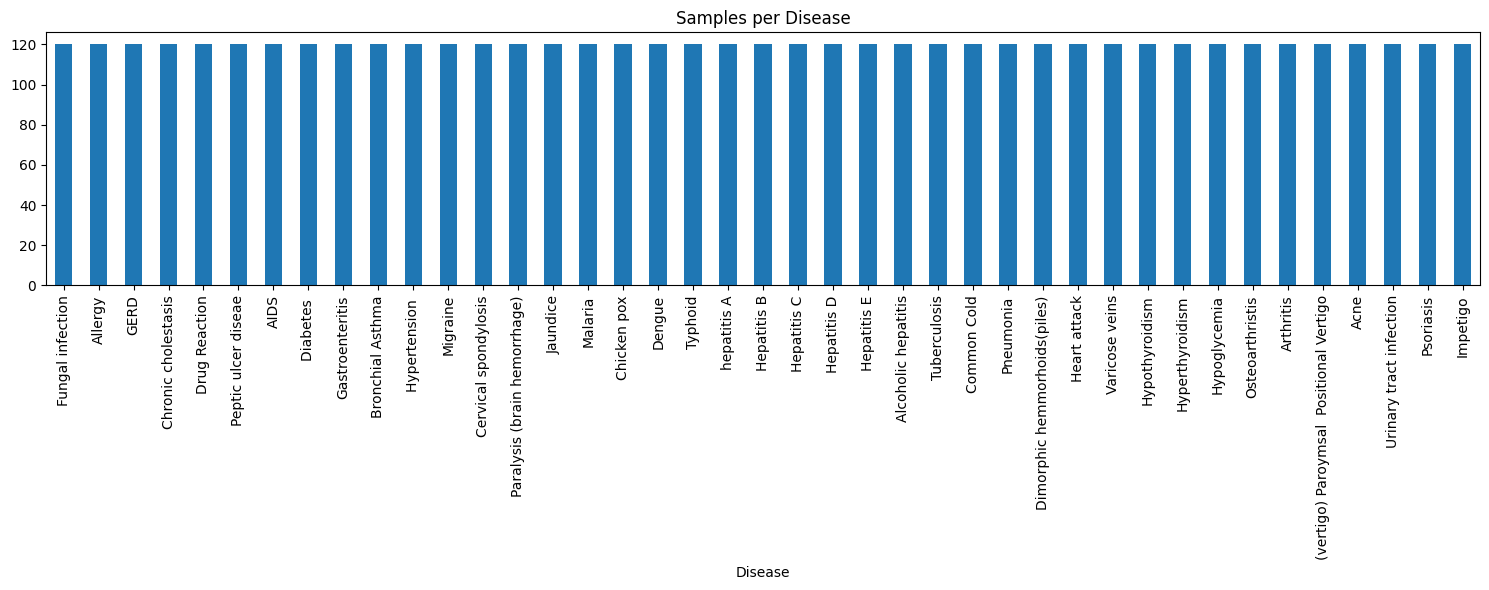

In [5]:
! pip install matplotlib
import matplotlib.pyplot as plt

# How many samples per disease?
disease_counts = binary_df['Disease'].value_counts()
print(disease_counts)

plt.figure(figsize=(15,6))
disease_counts.plot(kind='bar')
plt.title('Samples per Disease')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = binary_df.drop('Disease',axis=1)
y = binary_df['Disease']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y_encoded.shape}")
print(f"Total classes: {len(le.classes_)}")
print(f"Classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size: {X_test.shape}")


Features shape: (4920, 131)
Target shape: (4920,)
Total classes: 41
Classes: ['(vertigo) Paroymsal  Positional Vertigo' 'AIDS' 'Acne'
 'Alcoholic hepatitis' 'Allergy' 'Arthritis' 'Bronchial Asthma'
 'Cervical spondylosis' 'Chicken pox' 'Chronic cholestasis' 'Common Cold'
 'Dengue' 'Diabetes ' 'Dimorphic hemmorhoids(piles)' 'Drug Reaction'
 'Fungal infection' 'GERD' 'Gastroenteritis' 'Heart attack' 'Hepatitis B'
 'Hepatitis C' 'Hepatitis D' 'Hepatitis E' 'Hypertension '
 'Hyperthyroidism' 'Hypoglycemia' 'Hypothyroidism' 'Impetigo' 'Jaundice'
 'Malaria' 'Migraine' 'Osteoarthristis' 'Paralysis (brain hemorrhage)'
 'Peptic ulcer diseae' 'Pneumonia' 'Psoriasis' 'Tuberculosis' 'Typhoid'
 'Urinary tract infection' 'Varicose veins' 'hepatitis A']

Train size: (3936, 131)
Test size: (984, 131)


Training XGBoost...
XGBoost trained!

XGBoost Accuracy: 100.00%

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                    

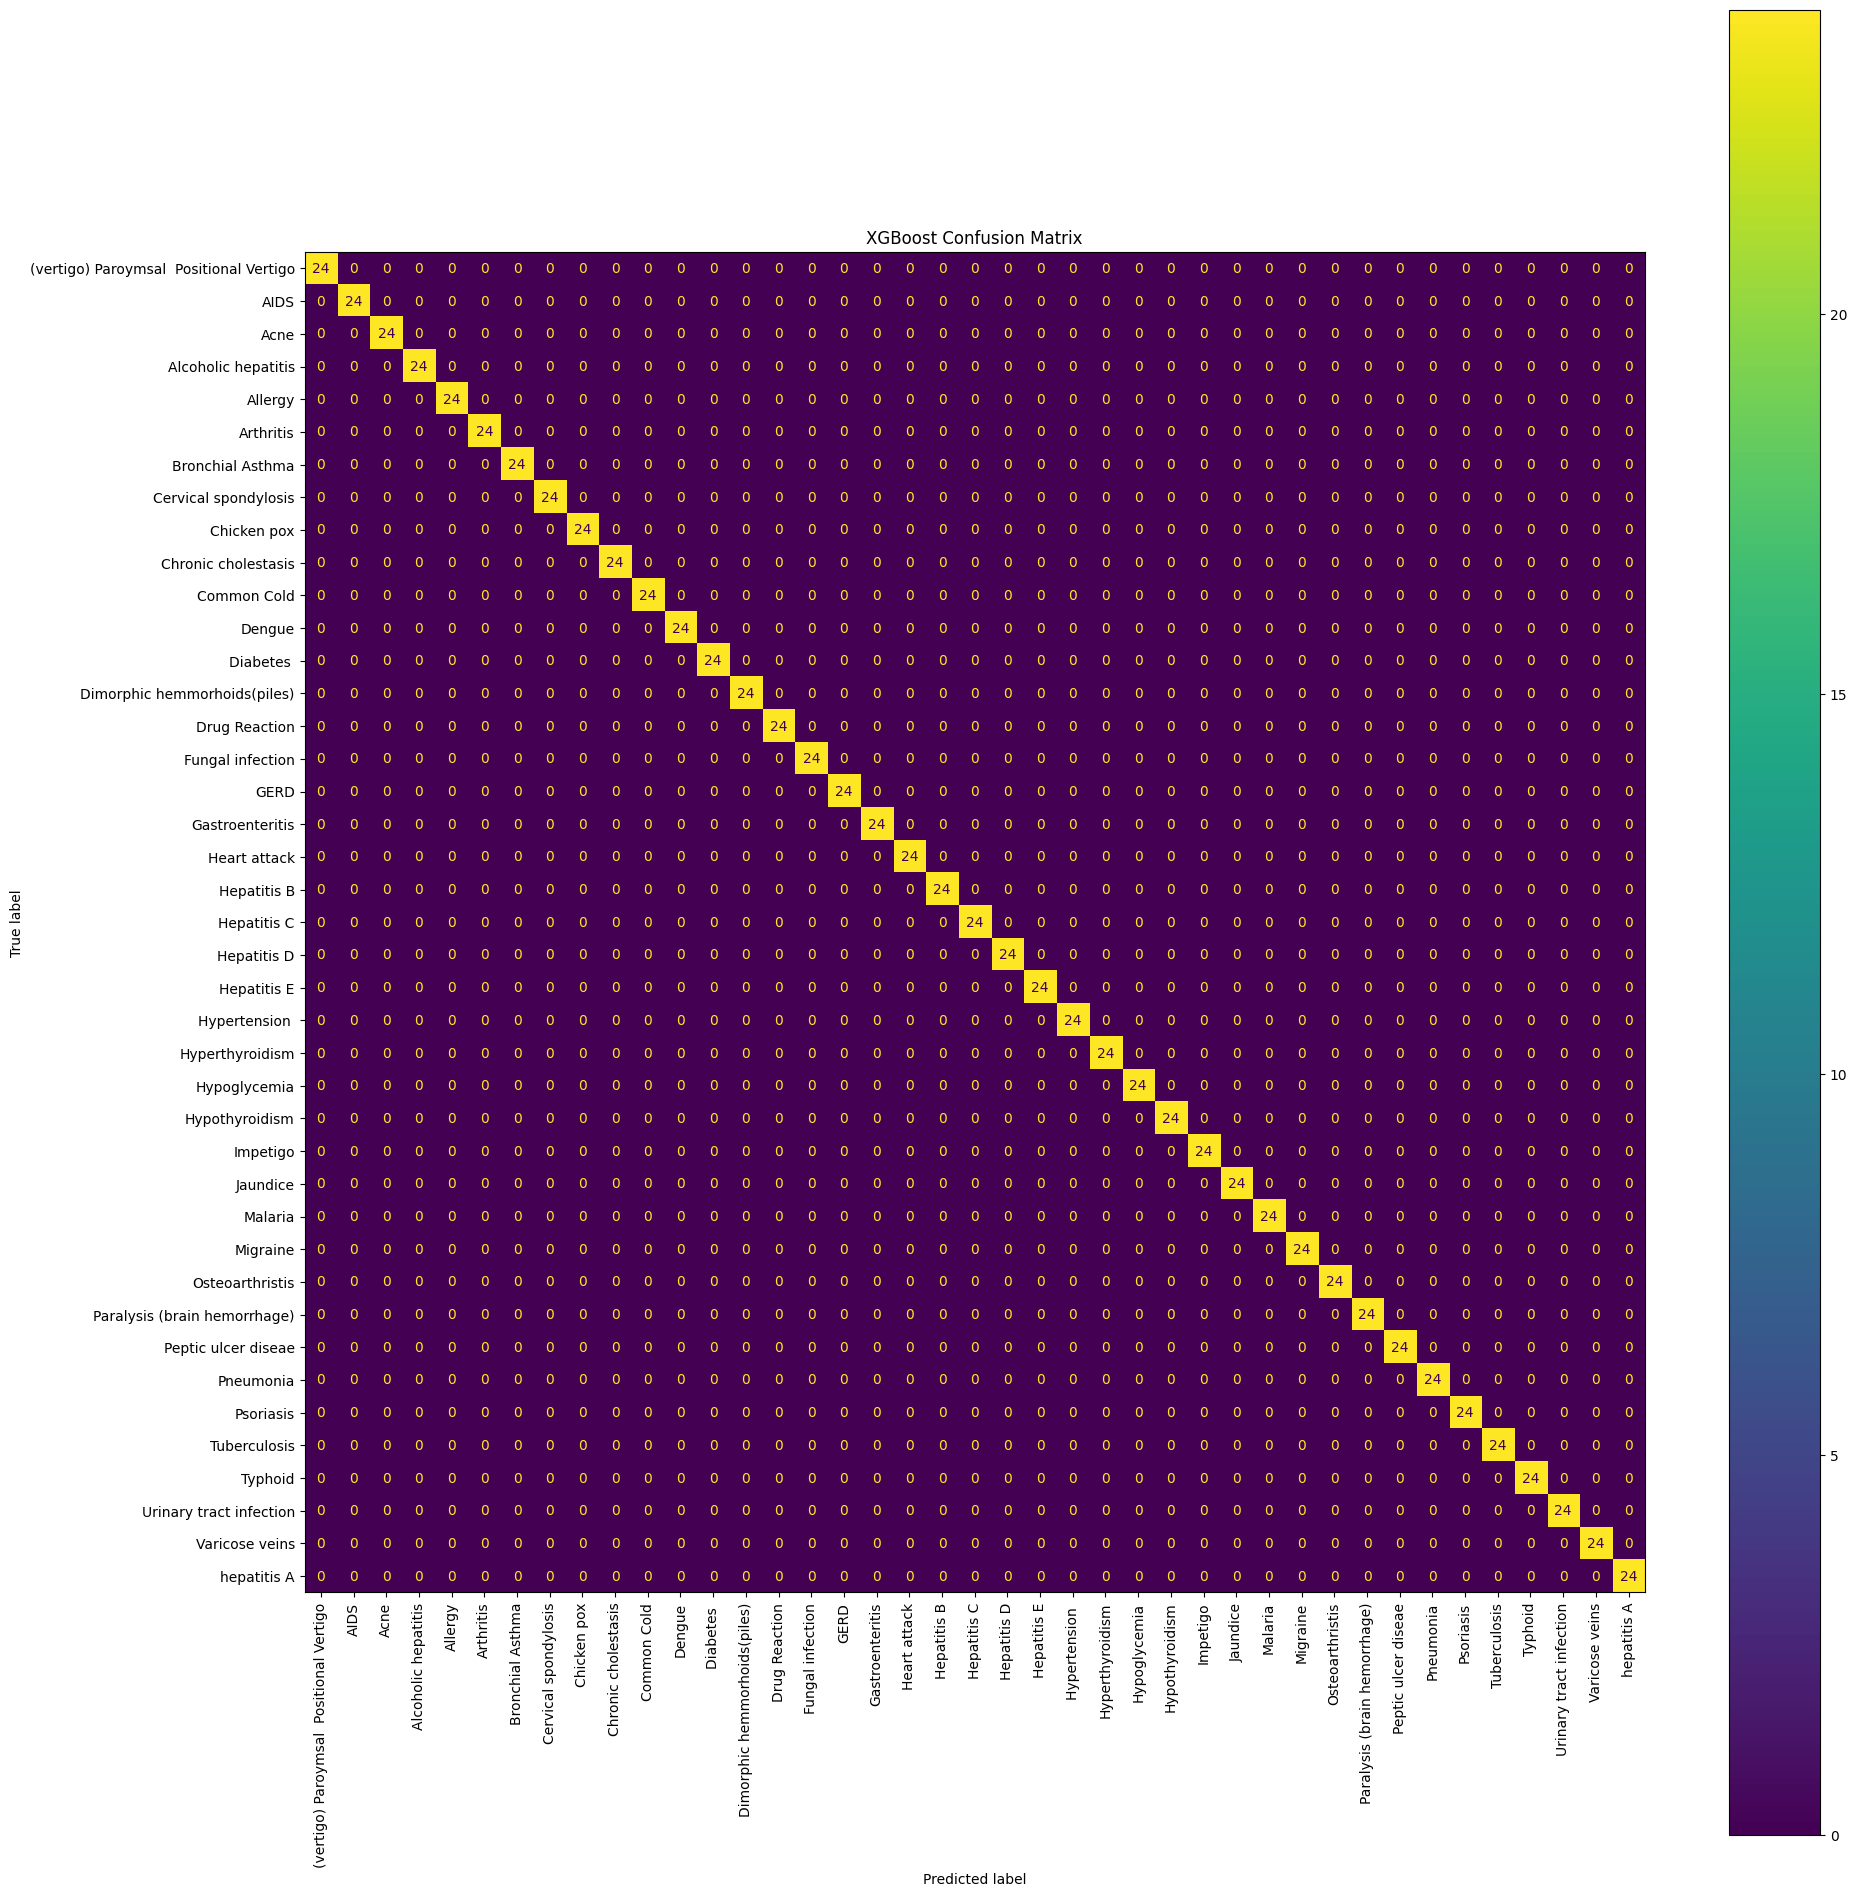


Model saved to models/!


In [9]:
! pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,      # 200 trees
    max_depth=6,           # how deep each tree goes
    learning_rate=0.1,     # how fast it learns
    random_state=42,
    eval_metric='mlogloss' # multi-class log loss
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained!")

# Evaluate
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nXGBoost Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model, X, y_encoded, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=plt.gca(), xticks_rotation=90)
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()
# Save model
import pickle
with open("models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open("models/symptom_list.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print("\nModel saved to models/!")

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoader — batches data for efficient training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Input features: {X_train_tensor.shape[1]}")
print(f"Output classes: {len(le.classes_)}")
print(f"Training batches: {len(train_loader)}")

Input features: 131
Output classes: 41
Training batches: 123


In [11]:
# ---- Define Neural Network Architecture ----
class DiseaseClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DiseaseClassifier, self).__init__()
        
        # Think of this as a pipeline:
        # 131 symptoms → 256 neurons → 128 neurons → 64 neurons → 41 diseases
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 256),  # 131 inputs → 256 neurons
            nn.ReLU(),                    # activation — adds non-linearity
            nn.BatchNorm1d(256),          # normalizes outputs — speeds up training
            nn.Dropout(0.3),             # randomly drops 30% neurons — prevents overfitting
            
            # Layer 2
            nn.Linear(256, 128),         # 256 → 128 neurons
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            # Layer 3
            nn.Linear(128, 64),          # 128 → 64 neurons
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            
            # Output layer
            nn.Linear(64, output_size)   # 64 → 41 diseases
            # No activation here — CrossEntropyLoss handles it internally
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
input_size = X_train_tensor.shape[1]   # 131
hidden_size = 256
output_size = len(le.classes_)          # 41

model = DiseaseClassifier(input_size, hidden_size, output_size)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

DiseaseClassifier(
  (network): Sequential(
    (0): Linear(in_features=131, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=41, bias=True)
  )
)

Total parameters: 78,505


In [12]:
# ---- Training Setup ----
criterion = nn.CrossEntropyLoss()  # loss function for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer — adaptive learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)  # reduce LR every 20 epochs

# ---- Training Loop ----
epochs = 100
train_losses = []
train_accuracies = []

print("Training Neural Network...")
for epoch in range(epochs):
    model.train()  # set to training mode — enables dropout and batchnorm
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass — input goes through network
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass — calculate gradients
        optimizer.zero_grad()  # clear previous gradients
        loss.backward()        # calculate new gradients
        optimizer.step()       # update weights
        
        total_loss += loss.item()
        
        # Calculate batch accuracy
        _, predicted = torch.max(outputs, 1)  # get class with highest score
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    scheduler.step()  # update learning rate
    
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total * 100
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete!")

Training Neural Network...
Epoch [10/100] Loss: 0.0066 Accuracy: 100.00%
Epoch [20/100] Loss: 0.0016 Accuracy: 100.00%
Epoch [30/100] Loss: 0.0009 Accuracy: 100.00%
Epoch [40/100] Loss: 0.0005 Accuracy: 100.00%
Epoch [50/100] Loss: 0.0003 Accuracy: 100.00%
Epoch [60/100] Loss: 0.0002 Accuracy: 100.00%
Epoch [70/100] Loss: 0.0002 Accuracy: 100.00%
Epoch [80/100] Loss: 0.0001 Accuracy: 100.00%
Epoch [90/100] Loss: 0.0001 Accuracy: 100.00%
Epoch [100/100] Loss: 0.0001 Accuracy: 100.00%

Training complete!


Neural Network Test Accuracy: 100.00%


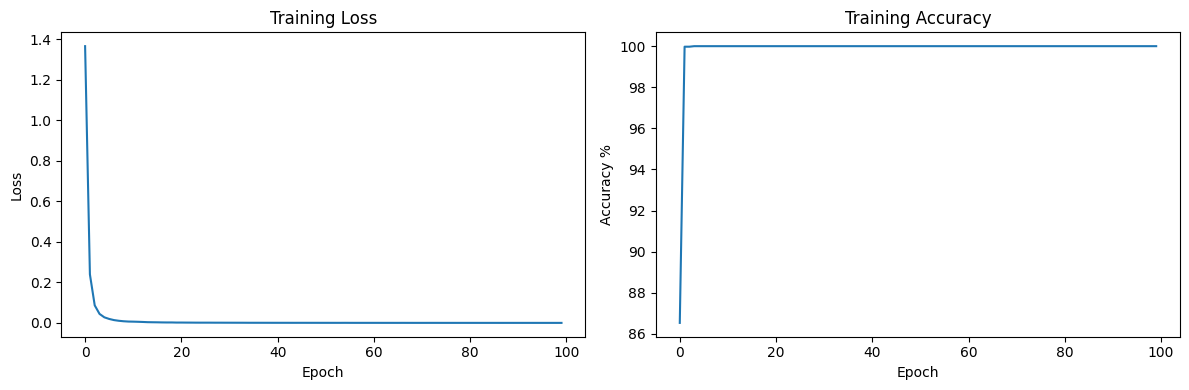

In [13]:
# ---- Evaluate on Test Set ----
model.eval()  # set to evaluation mode — disables dropout and batchnorm
with torch.no_grad():  # no gradient calculation needed for evaluation
    test_outputs = model(X_test_tensor)
    _, test_predicted = torch.max(test_outputs, 1)
    test_accuracy = (test_predicted == y_test_tensor).sum().item() / len(y_test_tensor) * 100

print(f"Neural Network Test Accuracy: {test_accuracy:.2f}%")

# Plot training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')

plt.tight_layout()
plt.show()

In [14]:
# Save Neural Network
torch.save(model.state_dict(), "models/neural_net.pt")
print("Neural network saved!")

Neural network saved!


In [15]:
print(f"Neural Network Test Accuracy: {test_accuracy:.2f}%")

Neural Network Test Accuracy: 100.00%


In [16]:
print("=" * 40)
print("      MODEL COMPARISON SUMMARY")
print("=" * 40)
print(f"XGBoost Accuracy:        100.00%")
print(f"Neural Network Accuracy: {test_accuracy:.2f}%")
print(f"XGBoost CV Score:        100.00% (+/- 0.00%)")
print("=" * 40)

      MODEL COMPARISON SUMMARY
XGBoost Accuracy:        100.00%
Neural Network Accuracy: 100.00%
XGBoost CV Score:        100.00% (+/- 0.00%)
